# StarCE Scalability Experiment

Evaluating the scalability of StarCE statistics collection along two dimensions:
1. **Data scale**: TPC-H (SF=1, 2, 4, 8, 16, 32, 64, 128)
2. **Thread count**: IMDB (threads=1, 2, 4, 8, 16)

In [ ]:
import os
import sys
from pathlib import Path
import time
import pandas as pd
import duckdb

sys.path.insert(0, str(Path.cwd()))
from ExperimentRunner import ExperimentRunner, StarCEConfig, StarCETestRunner

In [11]:
# ============================================================
# Experiment Configuration -- edit this cell before running
# ============================================================

# TPC-H scale factors to test (powers of 2 from 1 to 128)
CFG_SCALE_FACTORS = [1, 2, 4, 8, 16, 32, 64, 128]

# Thread counts to test (thread scale experiment)
CFG_THREAD_COUNTS = [1, 2, 4, 8, 16]

# Number of repeated runs per configuration (use 1 for a quick trial)
CFG_NUM_RUNS = 1

# Fixed thread count used during the data scale experiment
CFG_FIXED_THREADS = 8

# Directory where TPC-H .db files are stored
CFG_DB_DIR = Path(os.environ.get("TPCH_DB_DIR", "tpchdata"))

# Checkpoint directory for saving results
CFG_CHECKPOINT_DIR = Path("checkpoint/StarCE")
CFG_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)


## Step 1: Generate TPC-H Datasets

In [12]:
def generate_tpch_data(sf: float):
    db_path = CFG_DB_DIR / f"tpch_sf{sf}.db"
    if db_path.exists():
        print(f"Database {db_path} already exists, skipping")
        return db_path
    print(f"Generating TPC-H SF={sf}...")
    import time as _time
    t0 = _time.time()
    conn = duckdb.connect(str(db_path))
    conn.execute(f"CALL dbgen(sf={sf})")
    conn.close()
    elapsed = _time.time() - t0
    size_mb = db_path.stat().st_size / (1024 * 1024)
    print(f"Done: {elapsed:.2f}s, size: {size_mb:.2f} MB")
    return db_path


In [13]:
for sf in CFG_SCALE_FACTORS:
    generate_tpch_data(sf)


Database /home/user/tpchdata/tpch_sf1.db already exists, skipping
Database /home/user/tpchdata/tpch_sf2.db already exists, skipping
Database /home/user/tpchdata/tpch_sf4.db already exists, skipping
Database /home/user/tpchdata/tpch_sf8.db already exists, skipping
Database /home/user/tpchdata/tpch_sf16.db already exists, skipping
Database /home/user/tpchdata/tpch_sf32.db already exists, skipping
Database /home/user/tpchdata/tpch_sf64.db already exists, skipping
Database /home/user/tpchdata/tpch_sf128.db already exists, skipping


## Step 2: Data Scale Experiment (TPC-H)

In [14]:
class ScalabilityTestRunner(StarCETestRunner):

    def get_tpch_db_config(self, sf: float) -> StarCEConfig:
        config = StarCEConfig()
        config.DB_PATH = str(CFG_DB_DIR / f"tpch_sf{sf}.db")
        config.SCHEMA_PATH = str(self.benchmark_dir / "TPCH" / "schema_tpch.json")
        config.STATS_PATH = str(self.checkpoint_dir / "StarCE" / f"statistics_tpch_sf{sf}.json")
        return config

    def test_data_scale(self, scale_factors, num_runs=3, fixed_threads=8):
        results = []
        sep = "=" * 80
        for sf in scale_factors:
            self.result(sep)
            self.result(f"TPC-H SF={sf} (threads={fixed_threads})")
            self.result(sep)
            config = self.get_tpch_db_config(sf)
            config.RefreshStatistics = 1
            config.CollectParallel = fixed_threads

            # Warmup run (discarded) — eliminates cold-start bias:
            # first SF in the loop would otherwise pay OS page-cache /
            # filesystem metadata / DuckDB connection warmup costs
            self.result(f"Warmup run for SF={sf} (not counted)...")
            self.inner_test_build_time(config, f"TPC-H-SF{sf}-warmup", 1)

            # Timed runs
            avg_time, stats_size = self.inner_test_build_time(config, f"TPC-H-SF{sf}", num_runs)
            db_path = Path(config.DB_PATH)
            db_size = db_path.stat().st_size if db_path.exists() else 0
            results.append({
                "scale_factor": sf,
                "threads": fixed_threads,
                "build_time_sec": avg_time,
                "statistics_size_bytes": stats_size,
                "database_size_bytes": db_size,
            })
        return pd.DataFrame(results)

    def test_thread_scale(self, thread_counts, num_runs=3):
        results = []
        sep = "=" * 80
        for threads in thread_counts:
            self.result(sep)
            self.result(f"IMDB (threads={threads})")
            self.result(sep)
            config = self.get_imdb_db_config()
            config.RefreshStatistics = 1
            config.CollectParallel = threads
            avg_time, stats_size = self.inner_test_build_time(config, f"IMDB-{threads}threads", num_runs)
            db_path = self.project_root / "Benchmark" / "duckdb" / "imdb.db"
            db_size = db_path.stat().st_size if db_path.exists() else 0
            results.append({
                "threads": threads,
                "build_time_sec": avg_time,
                "statistics_size_bytes": stats_size,
                "database_size_bytes": db_size,
            })
        return pd.DataFrame(results)


runner = ScalabilityTestRunner()


In [ ]:
scale_results = runner.test_data_scale(
    scale_factors=CFG_SCALE_FACTORS,
    num_runs=CFG_NUM_RUNS,
    fixed_threads=CFG_FIXED_THREADS,
)

scale_results.to_csv(CFG_CHECKPOINT_DIR / "scalability_data_scale.csv", index=False)
scale_results


## Step 3: Thread Count Experiment (IMDB)

In [ ]:
thread_results = runner.test_thread_scale(
    thread_counts=CFG_THREAD_COUNTS,
    num_runs=CFG_NUM_RUNS,
)

thread_results.to_csv(CFG_CHECKPOINT_DIR / "scalability_thread_scale.csv", index=False)
thread_results


---
# Plotting

> The cells below can be run **independently**, only require checkpoint CSV files to exist, no need to re-execute experiments.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
# Checkpoint directory for reading results
CFG_CHECKPOINT_DIR = Path("checkpoint/StarCE")

## Visualization

Saved to checkpoint/StarCE/scalability_experiment.pdf


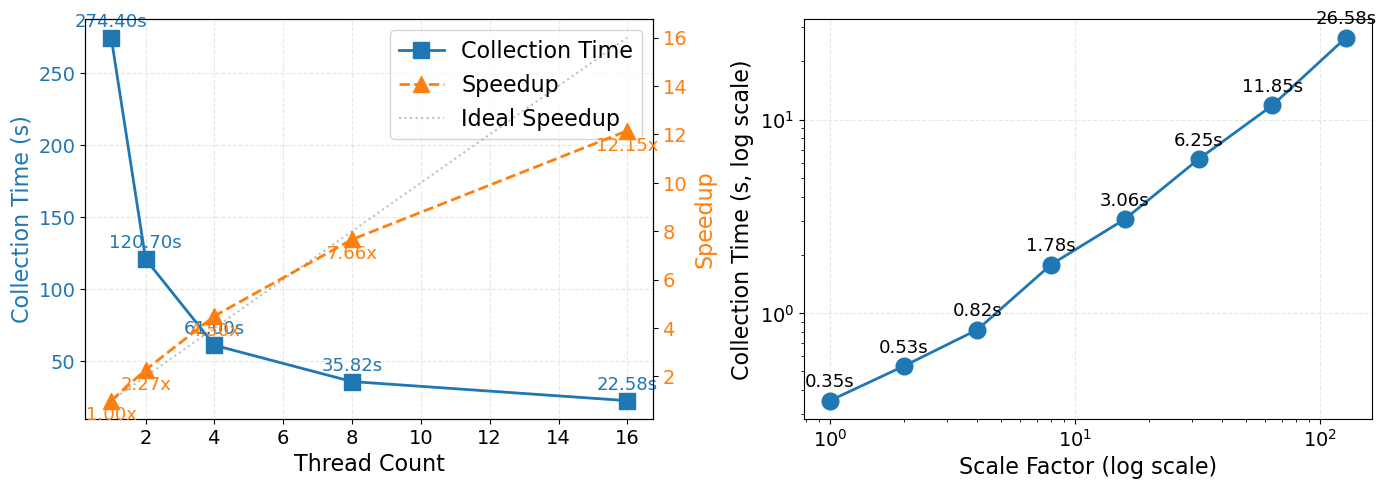

In [3]:
# Load results from checkpoint
scale_results = pd.read_csv(CFG_CHECKPOINT_DIR / "scalability_data_scale.csv")
thread_results = pd.read_csv(CFG_CHECKPOINT_DIR / "scalability_thread_scale.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Thread count vs collection time + speedup
ax1 = axes[0]
baseline_time = thread_results[thread_results["threads"] == 1]["build_time_sec"].values[0]
thread_results["speedup"] = baseline_time / thread_results["build_time_sec"]

ax1.plot(thread_results["threads"], thread_results["build_time_sec"],
         marker="s", linewidth=2, markersize=12, label="Collection Time", color="tab:blue")
ax1.set_xlabel("Thread Count", fontsize=16)
ax1.set_ylabel("Collection Time (s)", fontsize=16, color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue", labelsize=14)
ax1.tick_params(axis="x", labelsize=14)
ax1.grid(True, alpha=0.3, linestyle="--")

ax1_twin = ax1.twinx()
ax1_twin.plot(thread_results["threads"], thread_results["speedup"],
              marker="^", linewidth=2, markersize=12, label="Speedup",
              color="tab:orange", linestyle="--")
ax1_twin.plot(thread_results["threads"], thread_results["threads"],
              linestyle=":", color="gray", alpha=0.5, label="Ideal Speedup")
ax1_twin.set_ylabel("Speedup", fontsize=16, color="tab:orange")
ax1_twin.tick_params(axis="y", labelcolor="tab:orange", labelsize=14)

for _, row in thread_results.iterrows():
    ax1.annotate(f"{row['build_time_sec']:.2f}s",
                 (row["threads"], row["build_time_sec"]),
                 textcoords="offset points", xytext=(0, 8), ha="center", fontsize=13, color="tab:blue")
    ax1_twin.annotate(f"{row['speedup']:.2f}x",
                      (row["threads"], row["speedup"]),
                      textcoords="offset points", xytext=(0, -14), ha="center", fontsize=13, color="tab:orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=16)

# Plot 2: Data scale vs collection time
ax2 = axes[1]
ax2.plot(scale_results["scale_factor"], scale_results["build_time_sec"],
         marker="o", linewidth=2, markersize=12)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Scale Factor (log scale)", fontsize=16)
ax2.set_ylabel("Collection Time (s, log scale)", fontsize=16)
ax2.tick_params(labelsize=14)
ax2.grid(True, alpha=0.3, linestyle="--")

for _, row in scale_results.iterrows():
    ax2.annotate(f"{row['build_time_sec']:.2f}s",
                 (row["scale_factor"], row["build_time_sec"]),
                 textcoords="offset points", xytext=(0, 10), ha="center", fontsize=13)

plt.tight_layout()

output_path = CFG_CHECKPOINT_DIR / "scalability_experiment.pdf"
with PdfPages(output_path) as pdf:
    pdf.savefig(fig)
print(f"Saved to {output_path}")

plt.show()

Saved to checkpoint/StarCE/scalability_thread.pdf


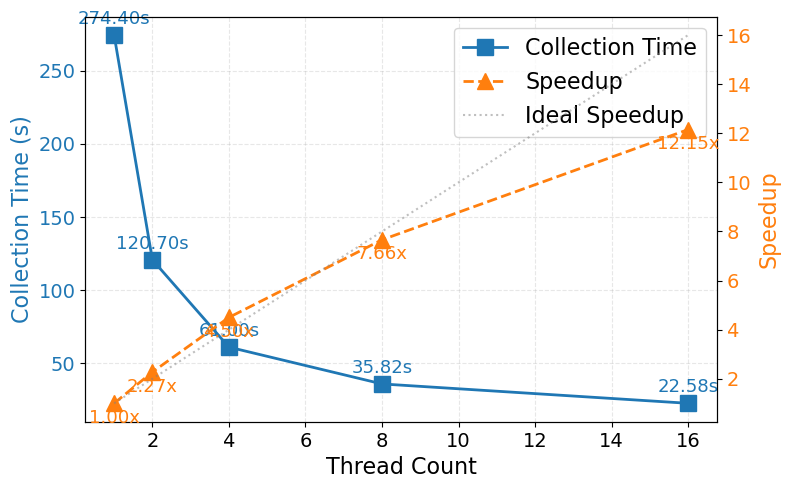

In [4]:
# Thread count plot (individual)
thread_results = pd.read_csv(CFG_CHECKPOINT_DIR / "scalability_thread_scale.csv")
baseline_time = thread_results[thread_results["threads"] == 1]["build_time_sec"].values[0]
thread_results["speedup"] = baseline_time / thread_results["build_time_sec"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(thread_results["threads"], thread_results["build_time_sec"],
        marker="s", linewidth=2, markersize=12, label="Collection Time", color="tab:blue")
ax.set_xlabel("Thread Count", fontsize=16)
ax.set_ylabel("Collection Time (s)", fontsize=16, color="tab:blue")
ax.tick_params(axis="y", labelcolor="tab:blue", labelsize=14)
ax.tick_params(axis="x", labelsize=14)
ax.grid(True, alpha=0.3, linestyle="--")

ax_twin = ax.twinx()
ax_twin.plot(thread_results["threads"], thread_results["speedup"],
             marker="^", linewidth=2, markersize=12, label="Speedup",
             color="tab:orange", linestyle="--")
ax_twin.plot(thread_results["threads"], thread_results["threads"],
             linestyle=":", color="gray", alpha=0.5, label="Ideal Speedup")
ax_twin.set_ylabel("Speedup", fontsize=16, color="tab:orange")
ax_twin.tick_params(axis="y", labelcolor="tab:orange", labelsize=14)

for _, row in thread_results.iterrows():
    ax.annotate(f"{row['build_time_sec']:.2f}s",
                (row["threads"], row["build_time_sec"]),
                textcoords="offset points", xytext=(0, 8), ha="center", fontsize=13, color="tab:blue")
    ax_twin.annotate(f"{row['speedup']:.2f}x",
                     (row["threads"], row["speedup"]),
                     textcoords="offset points", xytext=(0, -14), ha="center", fontsize=13, color="tab:orange")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=16)

plt.tight_layout()
output_path = CFG_CHECKPOINT_DIR / "scalability_thread.pdf"
with PdfPages(output_path) as pdf:
    pdf.savefig(fig)
print(f"Saved to {output_path}")
plt.show()

Saved to checkpoint/StarCE/scalability_data_scale.pdf


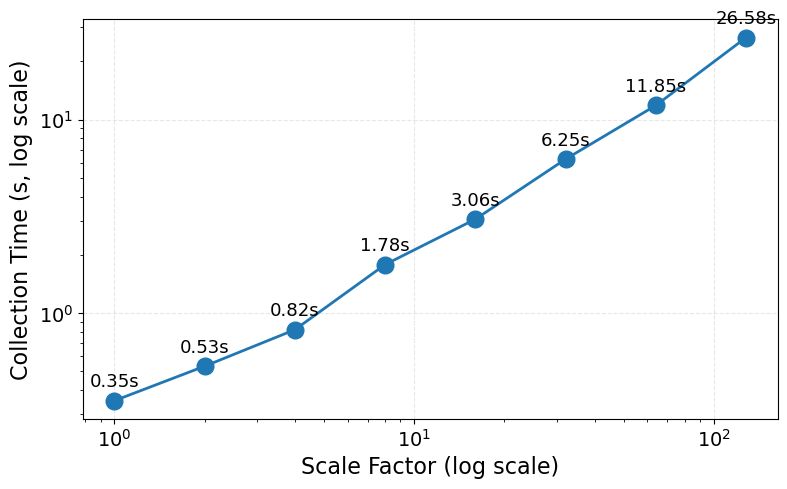

In [5]:
# Data scale plot (individual)
scale_results = pd.read_csv(CFG_CHECKPOINT_DIR / "scalability_data_scale.csv")

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(scale_results["scale_factor"], scale_results["build_time_sec"],
        marker="o", linewidth=2, markersize=12)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Scale Factor (log scale)", fontsize=16)
ax.set_ylabel("Collection Time (s, log scale)", fontsize=16)
ax.tick_params(labelsize=14)
ax.grid(True, alpha=0.3, linestyle="--")

for _, row in scale_results.iterrows():
    ax.annotate(f"{row['build_time_sec']:.2f}s",
                (row["scale_factor"], row["build_time_sec"]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=13)

plt.tight_layout()
output_path = CFG_CHECKPOINT_DIR / "scalability_data_scale.pdf"
with PdfPages(output_path) as pdf:
    pdf.savefig(fig)
print(f"Saved to {output_path}")
plt.show()

## Step 5: Summary Statistics

In [6]:
# Load from checkpoint
scale_results = pd.read_csv(CFG_CHECKPOINT_DIR / "scalability_data_scale.csv")
thread_results = pd.read_csv(CFG_CHECKPOINT_DIR / "scalability_thread_scale.csv")

scale_results["stats_size_mb"] = scale_results["statistics_size_bytes"] / (1024 * 1024)
scale_results["db_size_mb"] = scale_results["database_size_bytes"] / (1024 * 1024)
scale_results["compression_ratio"] = scale_results["db_size_mb"] / scale_results["stats_size_mb"]

print("Data scale results:")
print(scale_results[["scale_factor", "build_time_sec", "stats_size_mb", "db_size_mb", "compression_ratio"]])

# recompute speedup from raw data (it is not persisted in the CSV)
baseline_time = thread_results[thread_results["threads"] == 1]["build_time_sec"].values[0]
thread_results["speedup"] = baseline_time / thread_results["build_time_sec"]

print()
print("Thread scale results:")
print(thread_results[["threads", "build_time_sec", "speedup"]])

Data scale results:
   scale_factor  build_time_sec  stats_size_mb    db_size_mb  \
0             1        0.352349       0.003245    252.011719   
1             2        0.531176       0.003291    503.761719   
2             4        0.820392       0.003291   1007.261719   
3             8        1.781439       0.003291   2039.761719   
4            16        3.057546       0.003383   4126.261719   
5            32        6.249368       0.003367   8332.511719   
6            64       11.847128       0.003413  16740.011719   
7           128       26.577831       0.003230  33543.261719   

   compression_ratio  
0       7.765308e+04  
1       1.530665e+05  
2       3.060535e+05  
3       6.197755e+05  
4       1.219819e+06  
5       2.474447e+06  
6       4.904491e+06  
7       1.038461e+07  

Thread scale results:
   threads  build_time_sec    speedup
0        1      274.398405   1.000000
1        2      120.700832   2.273376
2        4       61.000010   4.498334
3        8       35.8

## Summary

Results saved to:
- `checkpoint/StarCE/scalability_data_scale.csv`
- `checkpoint/StarCE/scalability_thread_scale.csv`
- `checkpoint/StarCE/scalability_experiment.pdf`